### Doc2Vec
- Word2Vec의 확장판 
- 기본적인 매개변수, 속성, 메서드는 Word2Vec과 같다. 
- 추가적인 부분이 존재 
- 매개변수 
    - dm
        - 기본값 : 1
        - 학습 알고리즘을 선택 
        - 1 : PV-DM
        - 0 : PV-DBOW
    - dm_mean
        - 기본값 : 0
        - 문장 벡터의 계산 방식 (PV-DM)
        - 0 : 벡터들의 합산 ->  범위가 커지는 경우가 발생 -> 노이즈로 인한 성능의 저하가 발생 할수 있다. 
        - 1 : 벡터들의 평균
    - dm_concat
        - 기본값 : 0
        - pv-dm에서 문서 벡터와 문장 벡터를 결합 할것인가?
        - 결합을 하는 경우 차원이 급격하게 증가
    - dbow_words
        - 기본값 : 0
        - PV-DBOW 사용 시 단어 벡터도 동시에 학습할것인가
    - alpha / min_alpha
        - 기본값 : 0.025, 0.0001
        - 보폭의 크기 
        - 반복 학습을 할 때 경사하강법의 기본적인 메뉴얼 -> 너무 크면 둔감, 너무 작으면 매우 민감 
- 속성 
    - model.wv
        - 학습이 된 단어 벡터의 저장소
        - PV-DBOW방식을 이용하고 dbow_words가 0인 경우 -> 문서 벡터를 기준으로 단어 벡터를 생성(단어 벡터를 학습으로 지정했을때랑 비교하면 신뢰도 떨어진다.)
    - model.dv
        - 학습이 된 문장 벡터의 저장소
    - model.dv.index_to_key
        - 문서들의 ID값 리스트
- 메서드 
    - build_vocab()
        - 단어 / 단서 사전을 구성 
        - update 매개변수 : 기존 사전에 갱신을 할것인가? (기본값 : False)
    - train()
        - 사전이 구축이 된 뒤 직접 학습을 수행 
        - 기존에 학습이 된 모델에 train() 함수를 사용하게 되면 추가적인 학습이 진행
    - infer_vector()
        - 새로운 문장을 벡터화 
        - 추가 학습이 아닌 학습이 된 모델로 문장 벡터를 되돌려준다. 

- build_vocab(), train() 메서드를 이용하여 수동으로 학습을 설정 
    - 기존의 학습된 모델에 파인튜닝(추가 학습)도 가능
- 일반적으로는 객체 생성시 sentences에 데이터를 추가함으로 학습을 실행 
- 파인 튜닝(증분 학습)을 사용하는 이유?
    - 데이터의 양이 증가하면 성능이 오를수 있다. 
    - 분할 학습을 통해서 시간을 나눠서 사용 가능 
    - 기본의 학습 시킨 데이터와 유사한 데이터를 파인 튜닝하여 성능을 향상 

In [2]:
from konlpy.tag import Komoran
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np 
import re


In [4]:
docs = [
    '#나는 커피를 정말 좋아한다', 
    '%오늘 아침에 에스프레소 두 잔을 마셨다', 
    '카페라떼가 제일 맛있다고 생각한다', 
    '나는 차를 더 자주 마신다', 
    '녹차를 마시면 기분이 편안해진다', 
    '홍차는 향이 깊고 고급스러운 느낌이다', 
    '카페에서 책을 읽는 시간이 너무 좋다', 
    '허브티도 몸에 좋은거 같다'
]

In [8]:
komoran =Komoran()

# 특정 품사 사용
allow_pos = ['NNP', 'NNG', 'VV', 'VA', 'MAG', 'SL']
# 불용어 처리 
stop_word = ['하다', '되다', '이다', '것', '수', '거']

# 문자에서 불필요한 글자들을 제거 (정규화)
def nomalize(text):
    # 특수 문자, 공백에 대한 처리 
    text = re.sub(r"[^가-힣0-9a-zA-Z\s\.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text



In [15]:
def tokenize(text):
    text = nomalize(text)
    print(text)
    tokens = []
    for word, pos in komoran.pos(text):
        if pos in allow_pos:
            # 동사, 형용사에는 뒤에 '다' 문자를 추가 
            if pos in ['VV', 'VA']:
                word += '다'
            if word not in stop_word and len(word) > 1:
                tokens.append(word)
    return tokens

In [16]:
tokenize(docs[0])

나는 커피를 정말 좋아한다


['커피', '정말', '좋아하다']

In [17]:
tokenize_docs = [ tokenize(doc) for doc in docs ]
tokenize_docs

나는 커피를 정말 좋아한다
오늘 아침에 에스프레소 두 잔을 마셨다
카페라떼가 제일 맛있다고 생각한다
나는 차를 더 자주 마신다
녹차를 마시면 기분이 편안해진다
홍차는 향이 깊고 고급스러운 느낌이다
카페에서 책을 읽는 시간이 너무 좋다
허브티도 몸에 좋은거 같다


[['커피', '정말', '좋아하다'],
 ['오늘', '아침', '에스프레소', '마시다'],
 ['카페', '제일', '맛있다', '생각'],
 ['자주', '마시다'],
 ['녹차', '마시다', '기분', '편안'],
 ['홍차', '깊다', '고급', '느낌'],
 ['카페', '읽다', '시간', '너무', '좋다'],
 ['허브', '좋다', '같다']]

In [20]:
# doc2vec은 문장 하나씩에 ID을 붙여준다. 
tagged = []
for idx, token in enumerate(tokenize_docs):
    # idx : 위치
    # token : 리스트의 원소
    tagged.append(
        TaggedDocument(words = token, tags = [f"DOC_{idx}"])
    )
tagged

[TaggedDocument(words=['커피', '정말', '좋아하다'], tags=['DOC_0']),
 TaggedDocument(words=['오늘', '아침', '에스프레소', '마시다'], tags=['DOC_1']),
 TaggedDocument(words=['카페', '제일', '맛있다', '생각'], tags=['DOC_2']),
 TaggedDocument(words=['자주', '마시다'], tags=['DOC_3']),
 TaggedDocument(words=['녹차', '마시다', '기분', '편안'], tags=['DOC_4']),
 TaggedDocument(words=['홍차', '깊다', '고급', '느낌'], tags=['DOC_5']),
 TaggedDocument(words=['카페', '읽다', '시간', '너무', '좋다'], tags=['DOC_6']),
 TaggedDocument(words=['허브', '좋다', '같다'], tags=['DOC_7'])]

In [21]:
model = Doc2Vec(
    documents = tagged, 
    vector_size=100, 
    window = 3, 
    min_count = 1, 
    dm = 1, 
    dm_mean = 1, 
    epochs = 100, 
    seed = 42, 
    negative = 5    # 잘못된 단어 배치를 사용하여 학습에서 이용
)

In [22]:
len(model.dv)

8

In [23]:
len(model.wv)

25

In [24]:
def print_similities(doc_id):
    # 입력받은 id 문장의 벡터 값
    dic_vec = model.dv[f"DOC_{doc_id}"]

    # 각각의 문장들의 벡터 데이터를 리스트 생성 
    mat = np.array(
        [model.dv[f"DOC_{i}"] for i in range(len(docs)) ]
    )

    # 문장 벡터들을 dic_vec와 코사인 유사도를 구한다. 결과물이 2차원 -> 우리는 문장을 하나만 사용 -> 1차원으로 가능
    sims = cosine_similarity( [dic_vec], mat )[0]

    order = sims.argsort()[::-1]
    
    # 기존의 문장을 출력 
    print(f"기존의 문장 : {doc_id} -> {docs[doc_id]} ")
    for idx in order:
        print(f"    -> {idx} {docs[idx]}    |   cos = {sims[idx]}")

In [26]:
print_similities(2)

기존의 문장 : 2 -> 카페라떼가 제일 맛있다고 생각한다 
    -> 2 카페라떼가 제일 맛있다고 생각한다    |   cos = 1.0
    -> 6 카페에서 책을 읽는 시간이 너무 좋다    |   cos = 0.1916544884443283
    -> 0 #나는 커피를 정말 좋아한다    |   cos = 0.14228910207748413
    -> 5 홍차는 향이 깊고 고급스러운 느낌이다    |   cos = 0.124900221824646
    -> 4 녹차를 마시면 기분이 편안해진다    |   cos = 0.11250437796115875
    -> 7 허브티도 몸에 좋은거 같다    |   cos = 0.03103412687778473
    -> 1 %오늘 아침에 에스프레소 두 잔을 마셨다    |   cos = 0.029737889766693115
    -> 3 나는 차를 더 자주 마신다    |   cos = -0.19048240780830383


In [27]:
# 고차원의 벡터 데이터를 그래프 시각화 하기 위해서 차원 축소 라이브러리를 호출 
from sklearn.manifold import TSNE

In [29]:
X = np.array(
    [ model.dv[f"DOC_{idx}"] for idx in range(len(docs)) ]
)
X.shape

(8, 100)

In [32]:
tsne = TSNE(
    n_components=2, 
    perplexity= 5, 
    random_state=42, 
    max_iter= 2000
)

In [33]:
X_2d = tsne.fit_transform(X)
X_2d.shape

(8, 2)

In [34]:
X_2d

array([[  51.72632  ,  126.36359  ],
       [ -26.009577 , -102.342255 ],
       [  44.24018  ,   49.548267 ],
       [ -34.739983 ,  169.07404  ],
       [  80.93372  ,  -67.38712  ],
       [ -13.314478 ,  -29.08933  ],
       [ -37.261425 ,   56.76089  ],
       [ -71.568375 ,   -5.2501307]], dtype=float32)

In [35]:
import matplotlib.pyplot as plt 
import platform

In [36]:
# 그래프에서 한글 깨짐 방지
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
# 마이너스 기호 깨짐 방지 
plt.rcParams['axes.unicode_minus'] = False

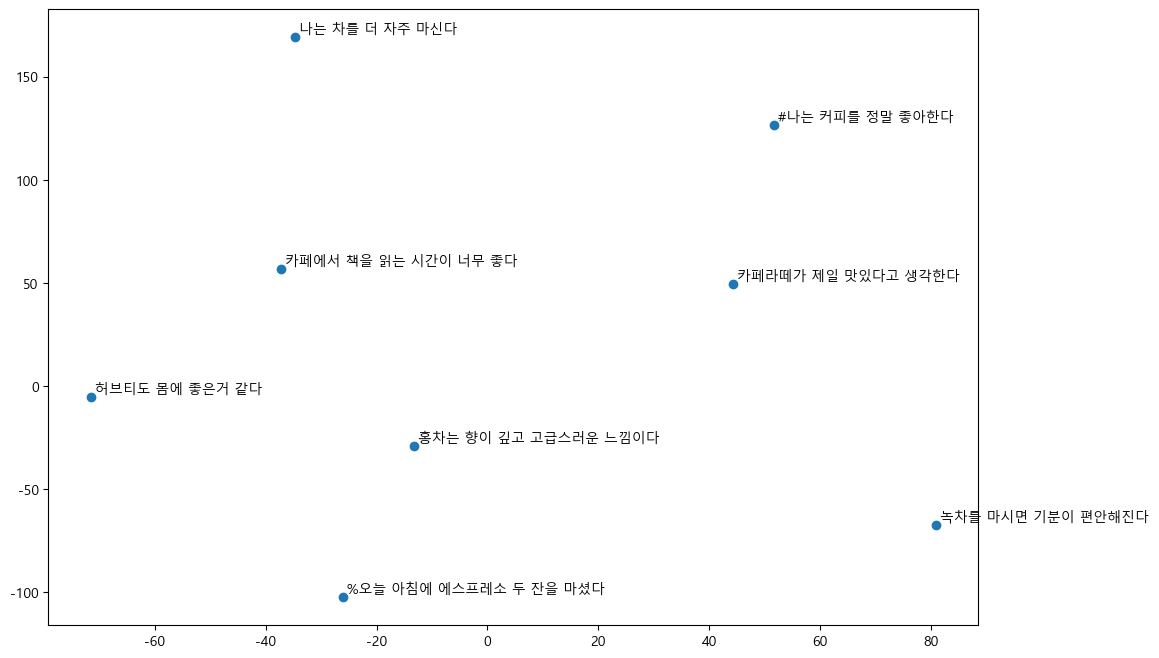

In [39]:
plt.figure(figsize=(12, 8))

# 산점도 그래프를 생성 
plt.scatter(
    X_2d[:, 0], X_2d[:, 1]
)

# 각각의 점에 주석을 달아주기 
for idx, text in enumerate(docs):
    plt.annotate(
        text, 
        xy = (X_2d[idx, 0], X_2d[idx, 1]), 
        xytext= (3, 3), 
        textcoords= 'offset points' # 각각의 위치에 텍스트 대입
    )



plt.show()

In [40]:
# 문장 별 벡터의 값을 이용하여 ML 학습 
# 독립변수 : 문장 벡터 
# 종속변수 : 커피(1) , 논커피(0) 데이터를 생성 
y = np.array([1, 1, 1, 0, 0, 0, 1, 0])

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [43]:
clf = LogisticRegression(random_state=42, max_iter=2000)

In [44]:
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [45]:
pred = clf.predict(X_test)
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.50      0.67         2

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



c:\Users\ekfla\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ekfla\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ekfla\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri